In [1]:
library(readxl)
library(ggplot2)


# Load SOFR data
df <- read_excel("ACF.xlsx", sheet = "SOFR")
names(df) <- trimws(names(df))
df$SOFR <- as.numeric(df$SOFR)

# Calculate ACF and PACF up to lag 100
acf_obj <- acf(na.omit(df$SOFR), lag.max = 100, plot = FALSE)
pacf_obj <- pacf(na.omit(df$SOFR), lag.max = 100, plot = FALSE)

# Data frames for plotting
acf_df <- data.frame(
  Lag = as.numeric(acf_obj$lag[, 1, 1]),
  Value = as.numeric(acf_obj$acf[, 1, 1]),
  Type = "ACF"
)
pacf_df <- data.frame(
  Lag = as.numeric(pacf_obj$lag),
  Value = as.numeric(pacf_obj$acf),
  Type = "PACF"
)

# Combine for faceted plot
plot_df <- rbind(acf_df, pacf_df)
# (Optional) Exclude lag 0 from PACF if you want matching axis
# plot_df <- subset(plot_df, Lag != 0 & !(Type == "PACF" & Lag == 0))

# 95% confidence interval
n <- sum(!is.na(df$SOFR))
ci <- qnorm(0.975)/sqrt(n)

# Plot ACF & PACF together
ggplot(plot_df, aes(x = Lag, y = Value)) +
  geom_bar(stat = "identity", width = 0.5, fill = "#1a85ff") +
  geom_hline(yintercept = 0, color = "black") +
  geom_hline(yintercept = c(-ci, ci), linetype = "dashed", color = "red") +
  facet_wrap(~Type, ncol = 1, scales = "free_y") +
  labs(
    title = "ACF and PACF of daily SOFR",
    x = "Lag",
    y = "Correlation"
  ) +
  theme_minimal(base_size = 14)


ERROR: Error: `path` does not exist: 'ACF.xlsx'


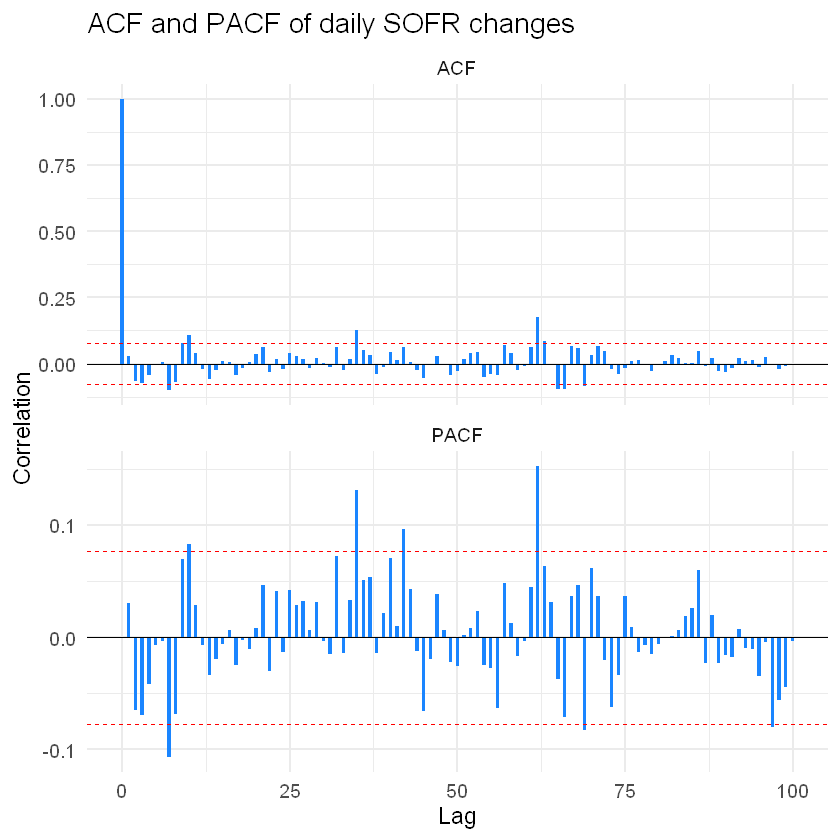

In [14]:
library(readxl)
library(ggplot2)


# Load SOFR data
df <- read_excel("ACF.xlsx", sheet = "Changes")
names(df) <- trimws(names(df))
df$SOFR <- as.numeric(df$SOFR)

# Calculate ACF and PACF up to lag 100
acf_obj <- acf(na.omit(df$SOFR), lag.max = 100, plot = FALSE)
pacf_obj <- pacf(na.omit(df$SOFR), lag.max = 100, plot = FALSE)

# Data frames for plotting
acf_df <- data.frame(
  Lag = as.numeric(acf_obj$lag[, 1, 1]),
  Value = as.numeric(acf_obj$acf[, 1, 1]),
  Type = "ACF"
)
pacf_df <- data.frame(
  Lag = as.numeric(pacf_obj$lag),
  Value = as.numeric(pacf_obj$acf),
  Type = "PACF"
)

# Combine for faceted plot
plot_df <- rbind(acf_df, pacf_df)
# (Optional) Exclude lag 0 from PACF if you want matching axis
# plot_df <- subset(plot_df, Lag != 0 & !(Type == "PACF" & Lag == 0))

# 95% confidence interval
n <- sum(!is.na(df$SOFR))
ci <- qnorm(0.975)/sqrt(n)

# Plot ACF & PACF together
ggplot(plot_df, aes(x = Lag, y = Value)) +
  geom_bar(stat = "identity", width = 0.5, fill = "#1a85ff") +
  geom_hline(yintercept = 0, color = "black") +
  geom_hline(yintercept = c(-ci, ci), linetype = "dashed", color = "red") +
  facet_wrap(~Type, ncol = 1, scales = "free_y") +
  labs(
    title = "ACF and PACF of daily SOFR changes",
    x = "Lag",
    y = "Correlation"
  ) +
  theme_minimal(base_size = 14)

Warning message in geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR"), :
"Ignoring unknown parameters: `inherit.aes`"
Warning message in geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR"), :
"Ignoring unknown parameters: `inherit.aes`"
Warning message in geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR changes"), :
"Ignoring unknown parameters: `inherit.aes`"
Warning message in geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR changes"), :
"Ignoring unknown parameters: `inherit.aes`"
Warning message:
"package 'ggtext' is in use and will not be installed"


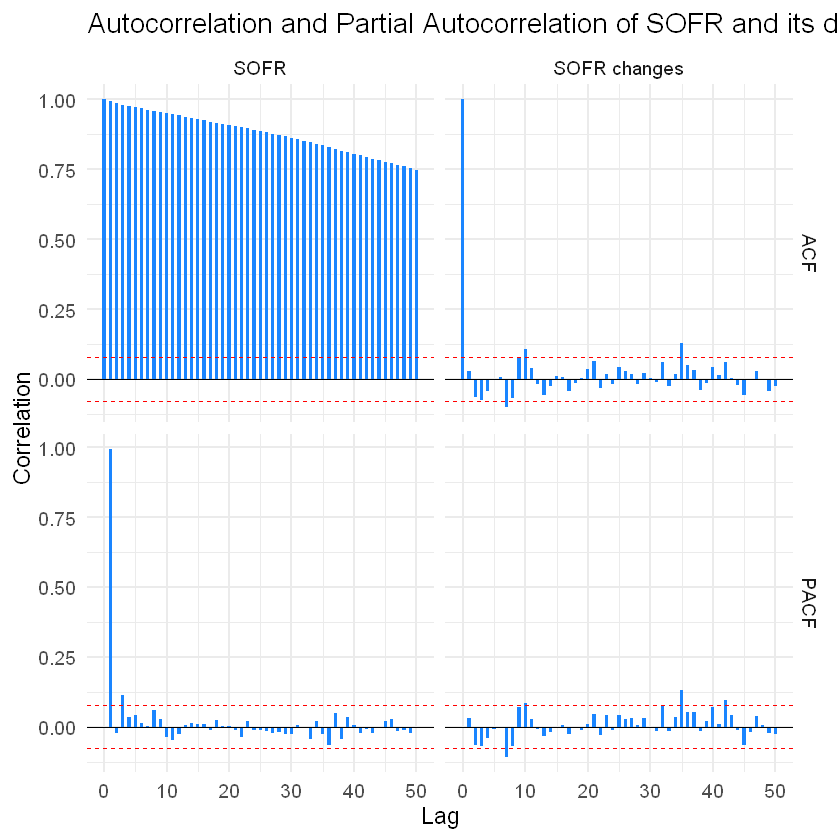

In [29]:
library(readxl)
library(ggplot2)

# Read SOFR raw and changes
df_sofr <- read_excel("ACF.xlsx", sheet = "SOFR")
names(df_sofr) <- trimws(names(df_sofr))
df_sofr$SOFR <- as.numeric(df_sofr$SOFR)

df_chg <- read_excel("ACF.xlsx", sheet = "Changes")
names(df_chg) <- trimws(names(df_chg))
df_chg$SOFR <- as.numeric(df_chg$SOFR)

# Calculate ACF and PACF for SOFR
acf_sofr <- acf(na.omit(df_sofr$SOFR), lag.max = 50, plot = FALSE)
pacf_sofr <- pacf(na.omit(df_sofr$SOFR), lag.max = 50, plot = FALSE)

acf_sofr_df <- data.frame(
  Lag = as.numeric(acf_sofr$lag[, 1, 1]),
  Value = as.numeric(acf_sofr$acf[, 1, 1]),
  Type = "ACF",
  Series = "SOFR"
)
pacf_sofr_df <- data.frame(
  Lag = as.numeric(pacf_sofr$lag),
  Value = as.numeric(pacf_sofr$acf),
  Type = "PACF",
  Series = "SOFR"
)

# Calculate ACF and PACF for SOFR changes
acf_chg <- acf(na.omit(df_chg$SOFR), lag.max = 50, plot = FALSE)
pacf_chg <- pacf(na.omit(df_chg$SOFR), lag.max = 50, plot = FALSE)

acf_chg_df <- data.frame(
  Lag = as.numeric(acf_chg$lag[, 1, 1]),
  Value = as.numeric(acf_chg$acf[, 1, 1]),
  Type = "ACF",
  Series = "SOFR changes"
)
pacf_chg_df <- data.frame(
  Lag = as.numeric(pacf_chg$lag),
  Value = as.numeric(pacf_chg$acf),
  Type = "PACF",
  Series = "SOFR changes"
)

# Combine all
plot_df <- rbind(acf_sofr_df, pacf_sofr_df, acf_chg_df, pacf_chg_df)

# 95% confidence intervals for SOFR and SOFR changes
n_sofr <- sum(!is.na(df_sofr$SOFR))
n_chg <- sum(!is.na(df_chg$SOFR))
ci_sofr <- qnorm(0.975) / sqrt(n_sofr)
ci_chg <- qnorm(0.975) / sqrt(n_chg)

# Plot, facetted by Type (rows) and Series (columns)
ggplot(plot_df, aes(x = Lag, y = Value)) +
  geom_bar(stat = "identity", width = 0.5, fill = "#1a85ff") +
  geom_hline(yintercept = 0, color = "black") +
  # Add correct CIs for each column
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR"), 
             aes(yintercept = ci_sofr), linetype = "dashed", color = "red", inherit.aes = FALSE) +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR"), 
             aes(yintercept = -ci_sofr), linetype = "dashed", color = "red", inherit.aes = FALSE) +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR changes"), 
             aes(yintercept = ci_chg), linetype = "dashed", color = "red", inherit.aes = FALSE) +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR changes"), 
             aes(yintercept = -ci_chg), linetype = "dashed", color = "red", inherit.aes = FALSE) +
  facet_grid(Type ~ Series, scales = "free_y") +
  labs(
    title = "Autocorrelation and Partial Autocorrelation of SOFR and its daily Changes",
    x = "Lag",
    y = "Correlation"
  ) +
  theme_minimal(base_size = 14)
install.packages("ggtext")

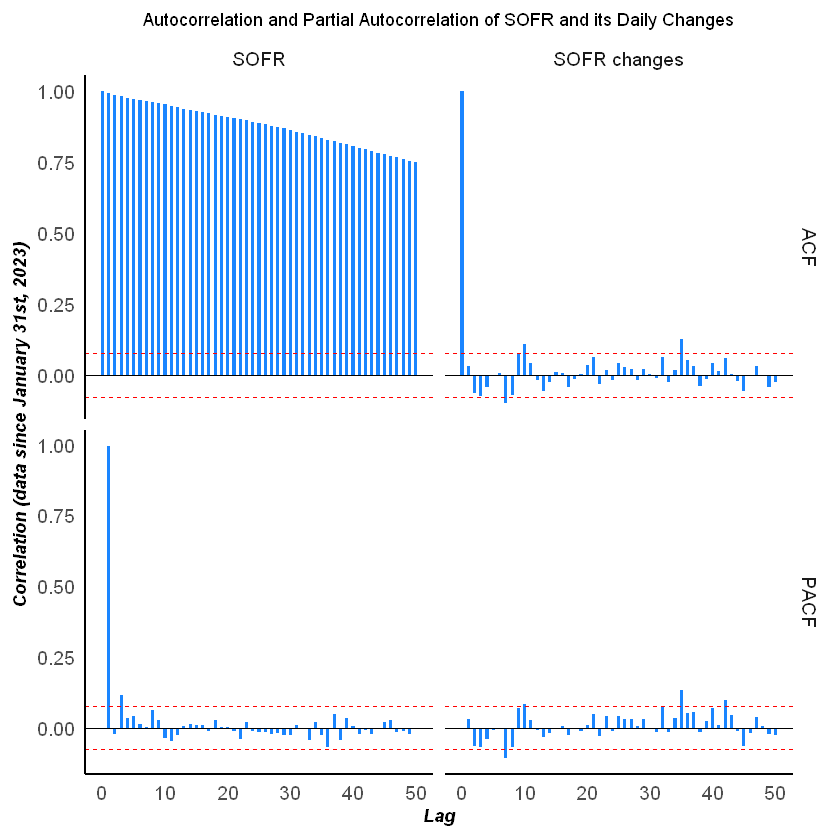

In [31]:
library(readxl)
library(ggplot2)

# Data prep as before...
df_sofr <- read_excel("ACF.xlsx", sheet = "SOFR")
names(df_sofr) <- trimws(names(df_sofr))
df_sofr$SOFR <- as.numeric(df_sofr$SOFR)
df_chg <- read_excel("ACF.xlsx", sheet = "Changes")
names(df_chg) <- trimws(names(df_chg))
df_chg$SOFR <- as.numeric(df_chg$SOFR)

acf_sofr <- acf(na.omit(df_sofr$SOFR), lag.max = 50, plot = FALSE)
pacf_sofr <- pacf(na.omit(df_sofr$SOFR), lag.max = 50, plot = FALSE)
acf_sofr_df <- data.frame(
  Lag = as.numeric(acf_sofr$lag[, 1, 1]),
  Value = as.numeric(acf_sofr$acf[, 1, 1]),
  Type = "ACF",
  Series = "SOFR"
)
pacf_sofr_df <- data.frame(
  Lag = as.numeric(pacf_sofr$lag),
  Value = as.numeric(pacf_sofr$acf),
  Type = "PACF",
  Series = "SOFR"
)
acf_chg <- acf(na.omit(df_chg$SOFR), lag.max = 50, plot = FALSE)
pacf_chg <- pacf(na.omit(df_chg$SOFR), lag.max = 50, plot = FALSE)
acf_chg_df <- data.frame(
  Lag = as.numeric(acf_chg$lag[, 1, 1]),
  Value = as.numeric(acf_chg$acf[, 1, 1]),
  Type = "ACF",
  Series = "SOFR changes"
)
pacf_chg_df <- data.frame(
  Lag = as.numeric(pacf_chg$lag),
  Value = as.numeric(pacf_chg$acf),
  Type = "PACF",
  Series = "SOFR changes"
)
plot_df <- rbind(acf_sofr_df, pacf_sofr_df, acf_chg_df, pacf_chg_df)

n_sofr <- sum(!is.na(df_sofr$SOFR))
n_chg <- sum(!is.na(df_chg$SOFR))
ci_sofr <- qnorm(0.975) / sqrt(n_sofr)
ci_chg <- qnorm(0.975) / sqrt(n_chg)

ggplot(plot_df, aes(x = Lag, y = Value)) +
  geom_bar(stat = "identity", width = 0.5, fill = "#1a85ff") +
  geom_hline(yintercept = 0, color = "black") +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR"), 
             aes(yintercept = ci_sofr), linetype = "dashed", color = "red") +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR"), 
             aes(yintercept = -ci_sofr), linetype = "dashed", color = "red") +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR changes"), 
             aes(yintercept = ci_chg), linetype = "dashed", color = "red") +
  geom_hline(data = data.frame(Type = c("ACF", "PACF"), Series = "SOFR changes"), 
             aes(yintercept = -ci_chg), linetype = "dashed", color = "red") +
  facet_grid(Type ~ Series, scales = "free_y") +
  labs(
    title = "Autocorrelation and Partial Autocorrelation of SOFR and its Daily Changes",
    x = expression(bolditalic("Lag")),
    y = expression(bolditalic("Correlation (data since January 31st, 2023)"))
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 11, face = "plain"),
    axis.title.x = element_text(size = 11, face = "bold.italic"),
    axis.title.y = element_text(size = 11, face = "bold.italic"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.6)
  )
